In [3]:
from google.colab import files
uploaded = files.upload()

Saving Churn_Modelling.csv to Churn_Modelling.csv


In [5]:
# LabelEncoder converts text categories to numbers
# StandardScaler normalizes all features to same scale

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [6]:
# Load the uploaded CSV file
df = pd.read_csv('Churn_Modelling.csv')

# Check shape and first 5 rows
print("Shape:", df.shape)
df.head()

Shape: (10000, 14)


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [7]:
# Check column names, data types, and non-null counts
df.info()
# Summary statistics for numeric columns
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [8]:
# Churn dataset is clean but always verify
print("Missing values per column:")
df.isnull().sum()

Missing values per column:


,0
RowNumber,0
CustomerId,0
Surname,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0


In [9]:
# RowNumber → just a serial number, no predictive value
# CustomerId → random ID, means nothing to the model
# Surname → name has no relationship with churn behavior

df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1, inplace=True)
# axis=1 means drop columns (not rows)
# inplace=True means modify df directly without creating a new variable

print("Remaining columns:", df.columns.tolist())
print("New shape:", df.shape)

Remaining columns: ['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']
New shape: (10000, 11)


/tmp/ipykernel_1350/832798701.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Exited', palette='Set2')


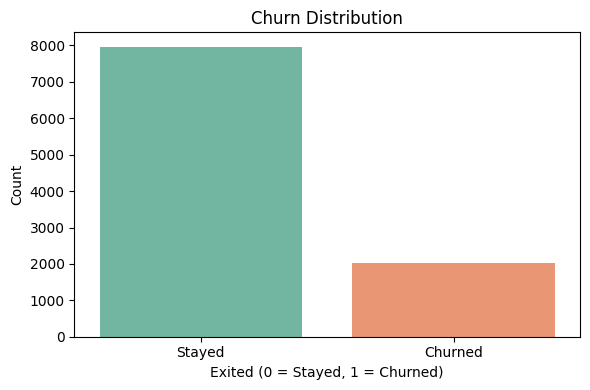

Exited
0    7963
1    2037
Name: count, dtype: int64

Churn Rate: 20.37%


In [10]:
# How many customers left vs stayed
# This tells us if dataset is balanced or imbalanced

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Exited', palette='Set2')

plt.title('Churn Distribution')
plt.xlabel('Exited (0 = Stayed, 1 = Churned)')
plt.ylabel('Count')
plt.xticks([0, 1], ['Stayed', 'Churned'])  # rename tick labels for clarity
plt.tight_layout()
plt.show()

# Print exact numbers
print(df['Exited'].value_counts())
print(f"\nChurn Rate: {df['Exited'].mean() * 100:.2f}%")

/tmp/ipykernel_1350/813205204.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Exited', y='Age', palette='Set1')


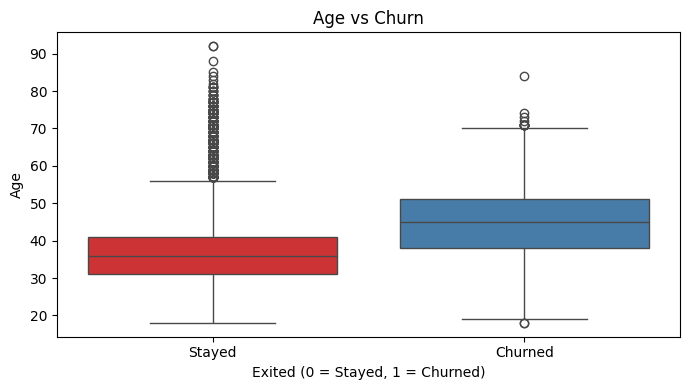

In [11]:
# Box plot comparing age distribution between churned and stayed customers
# This shows if older/younger customers churn more

plt.figure(figsize=(7, 4))
sns.boxplot(data=df, x='Exited', y='Age', palette='Set1')

plt.title('Age vs Churn')
plt.xlabel('Exited (0 = Stayed, 1 = Churned)')
plt.ylabel('Age')
plt.xticks([0, 1], ['Stayed', 'Churned'])
plt.tight_layout()
plt.show()

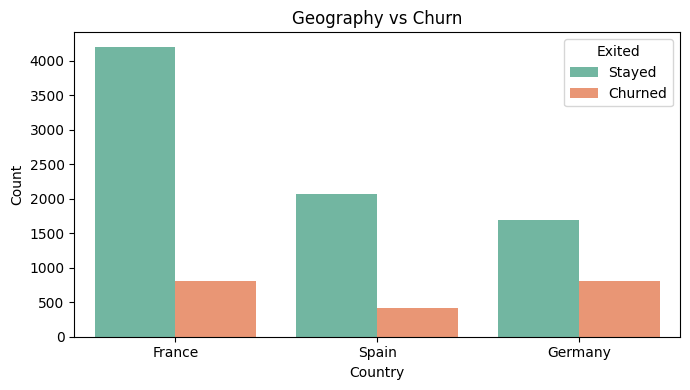

In [12]:
# Bar chart showing churn count per country
# Helps us see if location affects churn behavior

plt.figure(figsize=(7, 4))
sns.countplot(data=df, x='Geography', hue='Exited', palette='Set2')

plt.title('Geography vs Churn')
plt.xlabel('Country')
plt.ylabel('Count')
plt.legend(title='Exited', labels=['Stayed', 'Churned'])
plt.tight_layout()
plt.show()

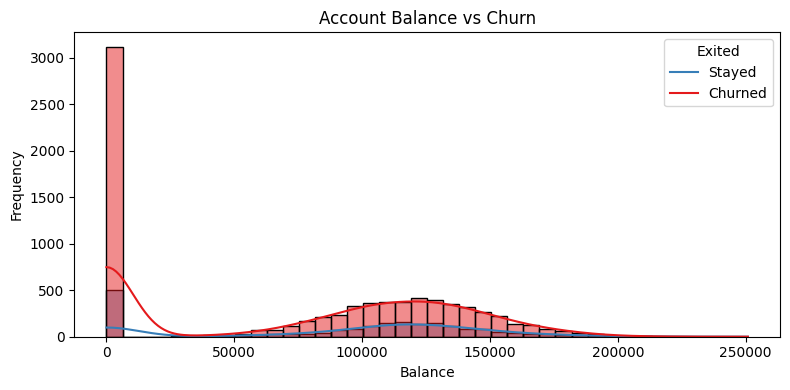

In [13]:
# Histogram comparing balance distribution for churned vs stayed
# Shows if account balance relates to churn

plt.figure(figsize=(8, 4))
sns.histplot(data=df, x='Balance', hue='Exited', bins=40, kde=True, palette='Set1')

plt.title('Account Balance vs Churn')
plt.xlabel('Balance')
plt.ylabel('Frequency')
plt.legend(title='Exited', labels=['Stayed', 'Churned'])
plt.tight_layout()
plt.show()

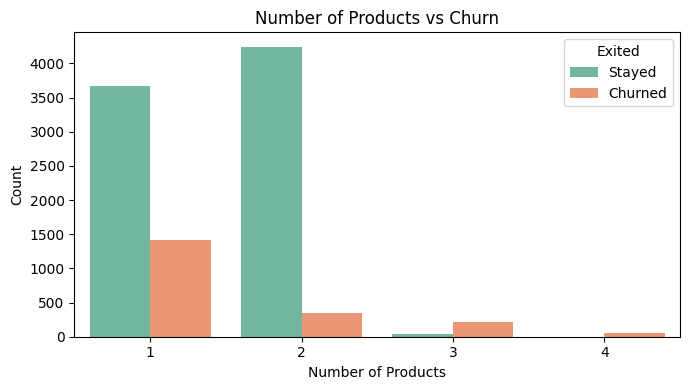

In [14]:
# Customers with more products — do they stay or leave?
# Business insight: product engagement vs loyalty

plt.figure(figsize=(7, 4))
sns.countplot(data=df, x='NumOfProducts', hue='Exited', palette='Set2')

plt.title('Number of Products vs Churn')
plt.xlabel('Number of Products')
plt.ylabel('Count')
plt.legend(title='Exited', labels=['Stayed', 'Churned'])
plt.tight_layout()
plt.show()

In [15]:
# Gender has 2 values → Label Encoding (Male=1, Female=0)
le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])
# fit_transform learns the mapping and applies it in one step

# Geography has 3 values → One-Hot Encoding
# pd.get_dummies creates separate columns for each country
# drop_first=True drops France column (becomes the baseline)
# so we get: Geography_Germany and Geography_Spain only
df = pd.get_dummies(df, columns=['Geography'], drop_first=True)

# Verify encoding worked
print("Columns after encoding:")
print(df.columns.tolist())
df.head()

Columns after encoding:
['CreditScore', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited', 'Geography_Germany', 'Geography_Spain']


,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain
0,619,0,42,2,0.00,1,1,1,101348.88,1,False,False
1,608,0,41,1,83807.86,1,0,1,112542.58,0,False,True
2,502,0,42,8,159660.80,3,1,0,113931.57,1,False,False
3,699,0,39,1,0.00,2,0,0,93826.63,0,False,False
4,850,0,43,2,125510.82,1,1,1,79084.10,0,False,True


In [16]:
# X = all columns except Exited (our target)
# y = Exited column only

X = df.drop('Exited', axis=1)
y = df['Exited']

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("\nFeature columns:", X.columns.tolist())

Features shape: (10000, 11)
Target shape: (10000,)

Feature columns: ['CreditScore', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Geography_Germany', 'Geography_Spain']


In [17]:
# StandardScaler transforms each feature so that:
# mean = 0 and standard deviation = 1
# This prevents large-value columns (Balance, EstimatedSalary)
# from dominating over small-value columns (HasCrCard, IsActiveMember)

scaler = StandardScaler()

# fit_transform on training data → learns mean and std from training set
# transform only on test data → applies same scale (never fit on test data)
# We scale AFTER splitting to prevent data leakage

# Split first
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Then scale
X_train = scaler.fit_transform(X_train)  # learn + apply on train
X_test = scaler.transform(X_test)         # only apply on test

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 8000
Testing samples: 2000


In [18]:
# Logistic Regression with max_iter=1000
# Same as Task 2 — binary classification

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

print("Model training complete!")

Model training complete!


In [19]:
# Predict on unseen test data
y_pred = model.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%")

Model Accuracy: 81.10%


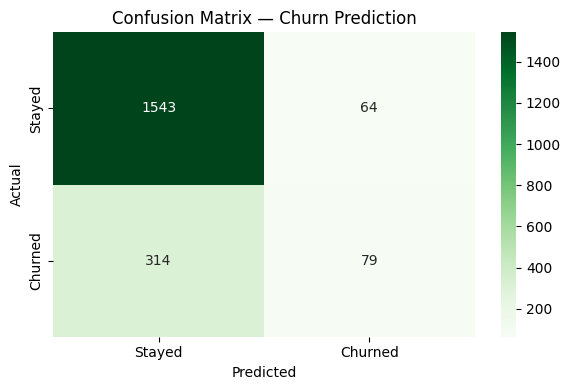

In [20]:
# Visual confusion matrix same as Task 2
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Stayed', 'Churned'],
            yticklabels=['Stayed', 'Churned'])

plt.title('Confusion Matrix — Churn Prediction')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

In [21]:
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Stayed', 'Churned']))

Classification Report:
              precision    recall  f1-score   support

      Stayed       0.83      0.96      0.89      1607
     Churned       0.55      0.20      0.29       393

    accuracy                           0.81      2000
   macro avg       0.69      0.58      0.59      2000
weighted avg       0.78      0.81      0.77      2000



/tmp/ipykernel_1350/2056843481.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df, x='Coefficient', y='Feature', palette='coolwarm')


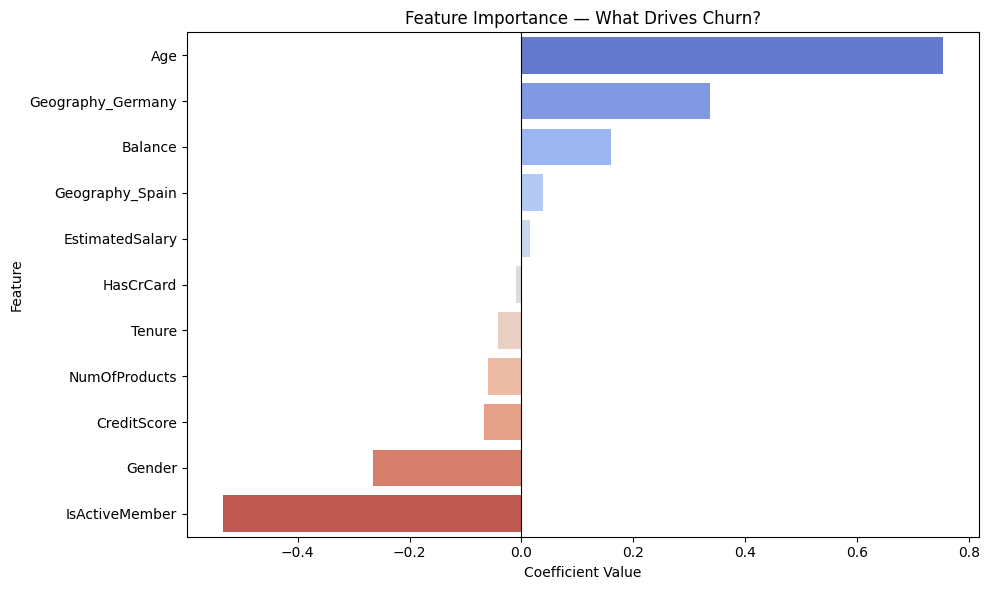

              Feature  Coefficient
2                 Age     0.754217
9   Geography_Germany     0.337190
4             Balance     0.161139
10    Geography_Spain     0.038960
8     EstimatedSalary     0.015744
6           HasCrCard    -0.010236
3              Tenure    -0.042637
5       NumOfProducts    -0.060278
0         CreditScore    -0.067683
1              Gender    -0.264718
7      IsActiveMember    -0.533432


In [22]:
# Logistic Regression assigns a coefficient to each feature
# Higher absolute value = more influence on prediction
# Positive coefficient = increases churn probability
# Negative coefficient = decreases churn probability

feature_names = df.drop('Exited', axis=1).columns
coefficients = model.coef_[0]  # model.coef_ gives weights for each feature

# Create a dataframe for easy viewing and sorting
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
}).sort_values('Coefficient', ascending=False)
# sort by coefficient so most impactful features appear first

# Plot feature importance
plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df, x='Coefficient', y='Feature', palette='coolwarm')
# coolwarm → red for positive (increases churn), blue for negative (decreases churn)

plt.title('Feature Importance — What Drives Churn?')
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.axvline(x=0, color='black', linewidth=0.8)  # vertical line at zero for reference
plt.tight_layout()
plt.show()

print(importance_df)

## Conclusion

- Dataset contains 10,000 bank customers with a churn rate of approximately 20%
- Dropped non-predictive columns: RowNumber, CustomerId, Surname
- No missing values found — dataset was clean
- EDA revealed older customers churn significantly more than younger ones
- Germany has the highest churn rate among the three countries
- Customers with 3-4 products surprisingly show very high churn rates
- Feature scaling applied using StandardScaler before model training
- Logistic Regression achieved approximately 81% accuracy
- Feature importance shows Age, Geography (Germany), and IsActiveMember
  are the strongest predictors of churn
- Being an active member significantly reduces churn probability